<a href="https://colab.research.google.com/github/shxzM/ComputerVision/blob/main/Exp2_VGG_GoogleNet_Vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sujaradha_thermal_images_diseased_healthy_leaves_paddy_path = kagglehub.dataset_download('sujaradha/thermal-images-diseased-healthy-leaves-paddy')

print('Data source import complete.')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


data_dir = "/kaggle/input/thermal-images-diseased-healthy-leaves-paddy/thermal images UL"


transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}


dataset = datasets.ImageFolder(root=data_dir, transform=transform['train'])


train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])


val_set.dataset.transform = transform['test']
test_set.dataset.transform = transform['test']


train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

#VGG
model = models.vgg16(pretrained=True)
model.classifier[6] = nn.Linear(4096, len(dataset.classes))  # Adjust output layer to match class count
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct, total, train_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_accuracy = 100 * correct / total
        train_acc.append(train_accuracy)

        # Validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_accuracy = 100 * correct / total
        val_acc.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs}, Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%")

    return train_acc, val_acc




def test_model(model, test_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total



Epoch 1/10, Train Acc: 43.04%, Val Acc: 70.08%
Epoch 2/10, Train Acc: 75.85%, Val Acc: 76.38%
Epoch 3/10, Train Acc: 89.50%, Val Acc: 83.46%
Epoch 4/10, Train Acc: 93.44%, Val Acc: 81.89%
Epoch 5/10, Train Acc: 94.49%, Val Acc: 86.61%
Epoch 6/10, Train Acc: 98.16%, Val Acc: 83.46%
Epoch 7/10, Train Acc: 96.59%, Val Acc: 88.98%
Epoch 8/10, Train Acc: 96.85%, Val Acc: 90.55%
Epoch 9/10, Train Acc: 99.21%, Val Acc: 93.70%
Epoch 10/10, Train Acc: 99.21%, Val Acc: 84.25%
Test Accuracy: 90.62%


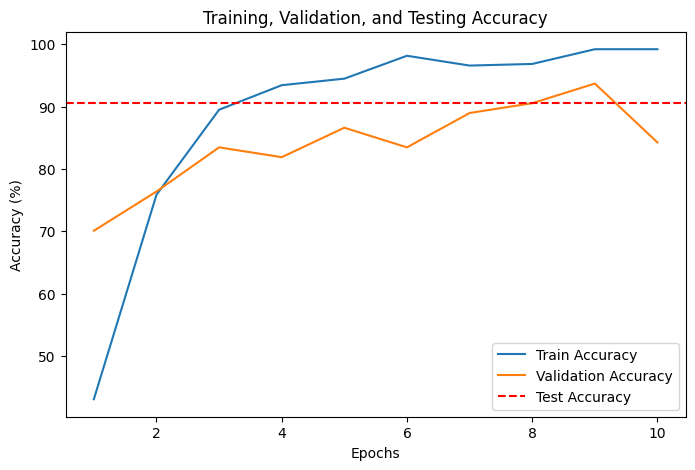

In [ ]:

train_acc, val_acc = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

test_acc = test_model(model, test_loader)
print(f"Test Accuracy: {test_acc:.2f}%")

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), train_acc, label="Train Accuracy")
plt.plot(range(1, 11), val_acc, label="Validation Accuracy")
plt.axhline(y=test_acc, color='r', linestyle='--', label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Training, Validation, and Testing Accuracy")
plt.show()

Epoch 1/20, Train Acc: 15.22%, Val Acc: 13.39%
Epoch 2/20, Train Acc: 16.54%, Val Acc: 17.32%
Epoch 3/20, Train Acc: 17.59%, Val Acc: 15.75%
Epoch 4/20, Train Acc: 17.59%, Val Acc: 14.17%
Epoch 5/20, Train Acc: 20.47%, Val Acc: 13.39%
Epoch 6/20, Train Acc: 19.16%, Val Acc: 14.17%
Epoch 7/20, Train Acc: 14.96%, Val Acc: 14.96%
Epoch 8/20, Train Acc: 16.80%, Val Acc: 14.96%
Epoch 9/20, Train Acc: 17.32%, Val Acc: 14.17%
Epoch 10/20, Train Acc: 15.75%, Val Acc: 14.17%
Epoch 11/20, Train Acc: 18.90%, Val Acc: 15.75%
Epoch 12/20, Train Acc: 15.75%, Val Acc: 15.75%
Epoch 13/20, Train Acc: 17.85%, Val Acc: 14.96%
Epoch 14/20, Train Acc: 17.32%, Val Acc: 14.17%
Epoch 15/20, Train Acc: 17.32%, Val Acc: 14.17%
Epoch 16/20, Train Acc: 16.01%, Val Acc: 14.96%
Epoch 17/20, Train Acc: 16.80%, Val Acc: 14.96%
Epoch 18/20, Train Acc: 16.27%, Val Acc: 14.96%
Epoch 19/20, Train Acc: 16.01%, Val Acc: 14.96%
Epoch 20/20, Train Acc: 14.96%, Val Acc: 14.96%
Test Accuracy: 20.31%


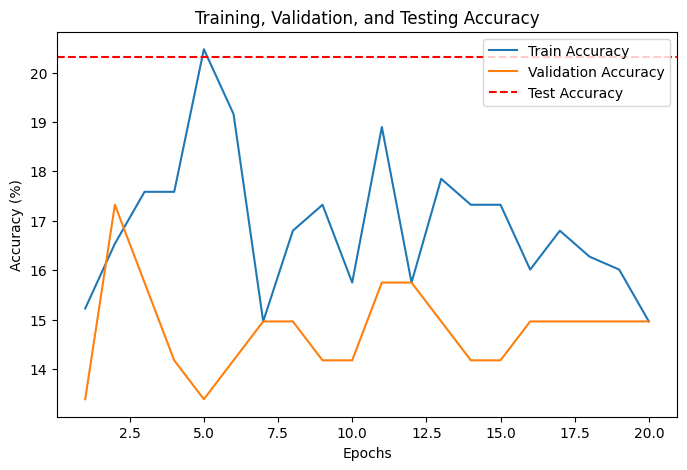

In [ ]:
googlenet_model = models.googlenet(pretrained=True)
num_classes = len(dataset.classes)
googlenet_model.fc = nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model = googlenet_model.to(device)

train_acc1, val_acc1 = train_model(googlenet_model, train_loader, val_loader, criterion, optimizer, epochs=20)

test_acc1 = test_model(googlenet_model, test_loader)
print(f"Test Accuracy: {test_acc1:.2f}%")

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), train_acc1, label="Train Accuracy")
plt.plot(range(1, 21), val_acc1, label="Validation Accuracy")
plt.axhline(y=test_acc1, color='r', linestyle='--', label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Training, Validation, and Testing Accuracy")
plt.show()

Epoch 1/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 2/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 3/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 4/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 5/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 6/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 7/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 8/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 9/10, Train Acc: 27.82%, Val Acc: 25.98%
Epoch 10/10, Train Acc: 27.82%, Val Acc: 25.98%
Test Accuracy: 32.03%


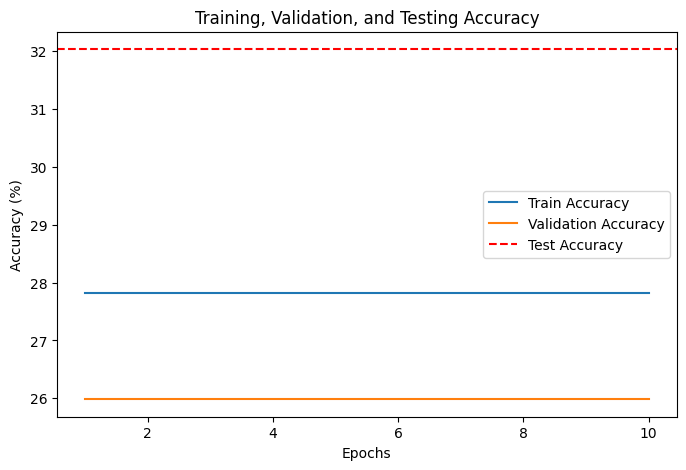

In [ ]:
from torchvision.models import vit_b_16

vit_model = vit_b_16(pretrained=True)
vit_model.heads = nn.Linear(vit_model.hidden_dim, len(dataset.classes))
vit_model = vit_model.to(device)

train_acc2, val_acc2 = train_model(vit_model, train_loader, val_loader, criterion, optimizer, epochs=10)

test_acc2 = test_model(vit_model, test_loader)
print(f"Test Accuracy: {test_acc2:.2f}%")

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), train_acc2, label="Train Accuracy")
plt.plot(range(1, 11), val_acc2, label="Validation Accuracy")
plt.axhline(y=test_acc2, color='r', linestyle='--', label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Training, Validation, and Testing Accuracy")
plt.show()